# EULP Model Training Notebook

- Samples the training subset **once** and reuses it across tuning steps
- Converts feature matrices to **float32 NumPy arrays** for faster training and lower memory use
- Uses **parallelized** `RandomizedSearchCV` with safer dispatch settings
- Keeps **XGBoost early stopping** while simplifying the tuning loop
- Adds **experiment metadata**, model persistence, and architecture persistence
- Removes obsolete / duplicate legacy cells from earlier experiments
- Makes the workflow more reproducible and easier to rerun

For large tabular datasets, these changes usually reduce runtime substantially while keeping the workflow reproducible.

In [1]:
# Core configuration
from __future__ import annotations

import gc
import json
import os
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.utils import check_random_state

import matplotlib.pyplot as plt
import shap

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
N_JOBS = -1
np.random.seed(SEED)

try:
    import xgboost as xgb
except ImportError as e:
    raise ImportError("xgboost is required for this notebook. Install it with `%pip install xgboost`.") from e

## Project paths

Update `PROJECT_ROOT` if your local project folder changes.

In [2]:
# Paths
PROJECT_ROOT = Path(r"./02_EULP_national")
DATA_DIR = PROJECT_ROOT / "03_Outcomes" / "01-Processed_Datasets"
MODEL_DIR = PROJECT_ROOT / "03_Outcomes" / "02-Models"
FIG_DIR = PROJECT_ROOT / "03_Outcomes" / "03_Figures"
SHAP_DIR = PROJECT_ROOT / "03_Outcomes" / "04_shap"

for path in [SHAP_DIR, FIG_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("DATA_DIR :", DATA_DIR)
print("MODEL_DIR   :", MODEL_DIR)
print("FIG_DIR :", FIG_DIR)
print("SHAP_DIR   :", SHAP_DIR)

DATA_DIR : .\02_EULP_national\03_Outcomes\01-Processed_Datasets
MODEL_DIR   : .\02_EULP_national\03_Outcomes\02-Models
FIG_DIR : .\02_EULP_national\03_Outcomes\03_Figures
SHAP_DIR   : .\02_EULP_national\03_Outcomes\04_shap


## Utility functions

In [3]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    err = y_true - y_pred
    return {
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "R2": float(r2_score(y_true, y_pred)),
    }


def sample_rows(X, y=None, n=200_000, random_state=SEED):
    rng = check_random_state(random_state)
    n_total = X.shape[0]
    idx = np.arange(n_total) if n >= n_total else rng.choice(n_total, size=n, replace=False)

    if y is None:
        return X[idx], idx
    return X[idx], y[idx], idx


def fit_predict_evaluate(model, X_train, y_train, X_test, y_test, model_name):
    t0 = time.time()
    model.fit(X_train, y_train)
    train_sec = time.time() - t0

    y_pred = model.predict(X_test)
    metrics = regression_metrics(y_test, y_pred)
    metrics["Model"] = model_name
    metrics["TrainTimeSec"] = float(train_sec)
    return y_pred, metrics


def summarize_array(name, arr):
    arr = np.asarray(arr)
    print(
        f"{name}: shape={arr.shape}, dtype={arr.dtype}, "
        f"memory={arr.nbytes / 1024**2:,.1f} MB"
    )

## Load data
- `X_train_scaled.csv`
- `X_test_scaled.csv`
- `y_train.csv`
- `y_test.csv`

In [4]:
# Load processed train/test data
X_train_df = pd.read_csv(DATA_DIR / "X_train_scaled.csv")
X_test_df = pd.read_csv(DATA_DIR / "X_test_scaled.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").iloc[:, 0].to_numpy(dtype=np.float32)
y_test = pd.read_csv(DATA_DIR / "y_test.csv").iloc[:, 0].to_numpy(dtype=np.float32)

DROP_COLS = ["bldg_id"]
X_train_df = X_train_df.drop(columns=DROP_COLS, errors="ignore")
X_test_df  = X_test_df.drop(columns=DROP_COLS, errors="ignore")

print("X_train_df:", X_train_df.shape)
print("X_test_df :", X_test_df.shape)
print("y_train   :", y_train.shape)
print("y_test    :", y_test.shape)

X_train_df: (439132, 311)
X_test_df : (109784, 311)
y_train   : (439132,)
y_test    : (109784,)


In [5]:
X_train_df.head()

,in.bedrooms,in.geometry_stories,in.sqft,in.cooling_setpoint,in.cooling_setpoint_offset_magnitude,in.geometry_building_number_units_mf,in.geometry_building_number_units_sfa,in.heating_setpoint,in.heating_setpoint_offset_magnitude,in.hot_water_fixtures,...,in.insulation_rim_joist_material=Uninsulated,in.insulation_roof_material=Finished,in.insulation_roof_material=Unfinished,in.insulation_wall_material=Brick 12-in 3-wythe,"in.insulation_wall_material=Brick, 12-in, 3-wythe",in.insulation_wall_material=CMU 6-in Hollow,"in.insulation_wall_material=CMU, 6-in Hollow",in.insulation_wall_material=Wood Stud,in.federal_poverty_level_ord,in.income_recs_2020_ord
0,-0.745161,-0.430258,-0.607290,1.343345,0.129509,-0.253220,-0.149811,0.001165,2.390996,-0.229303,...,-0.949672,-0.614692,0.614692,-0.352911,-0.327145,-0.139088,-0.118885,0.562482,-1.849199,-1.501176
1,0.221499,-0.430258,-0.038974,-0.649413,-0.659183,-0.253220,-0.149811,-0.981338,0.804590,-1.146941,...,1.052995,-0.614692,0.614692,-0.352911,-0.327145,-0.139088,8.411516,-1.777834,0.920237,0.344212
2,0.221499,-0.430258,-0.038974,1.343345,-0.659183,-0.253220,-0.149811,0.328666,0.011387,-0.229303,...,-0.949672,-0.614692,0.614692,2.833573,-0.327145,-0.139088,-0.118885,-1.777834,0.920237,0.344212
3,-0.745161,-0.430258,-0.370786,-0.151223,-0.659183,-0.253220,-0.149811,0.328666,-0.781816,1.605973,...,1.052995,-0.614692,0.614692,-0.352911,-0.327145,-0.139088,-0.118885,0.562482,-0.741425,-0.270917
4,-0.745161,8.612898,-0.629882,1.841535,-0.659183,8.186917,-0.149811,0.328666,-0.781816,1.605973,...,-0.949672,1.626831,-1.626831,-0.352911,-0.327145,-0.139088,-0.118885,0.562482,-0.741425,-0.886046


In [5]:
# Save feature list
feature_names = list(X_train_df.columns)
with open(MODEL_DIR / "features.json", "w") as f:
    json.dump(feature_names, f, indent=2)

In [6]:
# Convert to memory-efficient NumPy arrays （This step avoids repeated pandas overhead during model fitting.）

X_train = X_train_df.to_numpy(dtype=np.float32, copy=True)
X_test = X_test_df.to_numpy(dtype=np.float32, copy=True)

del X_train_df, X_test_df
gc.collect()

summarize_array("X_train", X_train)
summarize_array("X_test", X_test)
summarize_array("y_train", y_train)
summarize_array("y_test", y_test)

X_train: shape=(439132, 311), dtype=float32, memory=521.0 MB
X_test: shape=(109784, 311), dtype=float32, memory=130.2 MB
y_train: shape=(439132,), dtype=float32, memory=1.7 MB
y_test: shape=(109784,), dtype=float32, memory=0.4 MB


## Reusable tuning sample
This version samples once and reuses the same subset where appropriate.

In [8]:
RF_SAMPLE_N = min(100_000, X_train.shape[0])
NN_SAMPLE_N = min(75_000, X_train.shape[0])
ENET_SAMPLE_N = min(200_000, X_train.shape[0])
XGB_SAMPLE_N = min(200_000, X_train.shape[0])

X_rf_tune, y_rf_tune, rf_tune_idx = sample_rows(
    X_train, y_train, n=RF_SAMPLE_N, random_state=SEED
)

X_nn_tune, y_nn_tune, nn_tune_idx = sample_rows(
    X_train, y_train, n=NN_SAMPLE_N, random_state=SEED,  # can also use SEED+1
)

X_enet_tune, y_enet_tune, enet_tune_idx = sample_rows(
    X_train, y_train, n=ENET_SAMPLE_N, random_state=SEED
)

X_xgb_tune, y_xgb_tune, xgb_tune_idx = sample_rows(
    X_train, y_train, n=XGB_SAMPLE_N, random_state=SEED
)

## Search / tuning helpers

In [9]:
def tune_random_search(
    base_model,
    param_distributions,
    X_train,
    y_train,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    verbose=2,
    n_jobs=N_JOBS,
):
    t0 = time.time()

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        refit=True,
        n_jobs=n_jobs,
        random_state=random_state,
        verbose=verbose,
        pre_dispatch="2*n_jobs",
        return_train_score=False,
    )

    search.fit(X_train, y_train)

    log = {
        "best_params": search.best_params_,
        "best_cv_rmse": float(-search.best_score_),
        "n_iter": int(n_iter),
        "cv": int(cv),
        "sample_n": int(X_train.shape[0]),
        "tune_time_sec": float(time.time() - t0),
    }
    return search.best_estimator_, log


def tune_xgb_early_stopping(
    base_model,
    param_space,
    X_train,
    y_train,
    n_iter=20,
    eval_size=0.15,
    early_stopping_rounds=100,
    random_state=SEED,
):
    rng = check_random_state(random_state)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=eval_size, random_state=random_state
    )

    keys = list(param_space.keys())
    best = None
    best_rmse = np.inf
    t0 = time.time()

    pbar = tqdm(range(n_iter), desc="XGB manual tuning", dynamic_ncols=True)
    for _ in pbar:
        params = {}
        for k in keys:
            values = param_space[k]
            params[k] = values[rng.randint(len(values))]

        model = clone(base_model).set_params(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        best_iteration = getattr(model, "best_iteration", None)
        if best_iteration is None:
            best_iteration = model.n_estimators

        pred_val = model.predict(X_val)
        val_rmse = rmse(y_val, pred_val)

        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best = {
                "model": model,
                "params": params,
                "val_rmse": float(val_rmse),
                "best_iteration": int(best_iteration),
            }

    best["tune_time_sec"] = float(time.time() - t0)
    best["sample_n"] = int(X_train.shape[0])
    best["eval_size"] = float(eval_size)
    best["early_stopping_rounds"] = int(early_stopping_rounds)
    return best

def progress_bar(iterable, desc=None, total=None):
    return tqdm(
        iterable,
        desc=desc,
        total=total,
        dynamic_ncols=True,
        leave=True,
        bar_format="{l_bar}{bar}| {elapsed}"
    )

## Model definitions

In [10]:
rf_base = RandomForestRegressor(
    random_state=SEED,
    n_jobs=N_JOBS,
    bootstrap=True,
    max_samples=0.8,   # speed + regularization
    oob_score=False,
)

rf_space = {
    "n_estimators": [200, 400],          
    "max_depth": [15, 25, 35],           
    "min_samples_leaf": [2, 4, 8],       
    "min_samples_split": [10, 20],    
    "max_features": ["sqrt", 0.3],  
}

xgb_base = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    max_bin=256,
    n_estimators=5000,   # early stopping determines actual effective rounds
    learning_rate=0.05,
    n_jobs=N_JOBS,
    random_state=SEED,
)

xgb_space = {
    "max_depth": [3, 4, 6, 8, 10],
    "min_child_weight": [1, 5, 10, 20],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9, 1.0],
    "reg_alpha": [0.0, 1e-4, 1e-3, 1e-2],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

enet_base = ElasticNet(
    random_state=SEED,
    max_iter=5_000,
    selection="random",
)

enet_space = {
    "alpha": np.logspace(-5, 1, 60),
    "l1_ratio": np.linspace(0.0, 1.0, 21),
}

nn_base = MLPRegressor(
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    max_iter=600,
)

nn_space = {
    "hidden_layer_sizes": [(256, 128), (512, 256), (512, 256, 128)],
    "alpha": np.logspace(-6, -2, 10),
    "learning_rate_init": np.logspace(-4, -2, 8),
    "batch_size": [256, 512, 1024],
}

## Train and evaluate all models

In [5]:
all_models = {}
tuning_logs = {}
metrics_rows = {}
predictions = {}

In [12]:
# 1) Random Forest
for _ in progress_bar(range(1), desc="RF hyperparameter tuning", total=1):
        
    rf_best, rf_log = tune_random_search(
        rf_base,
        rf_space,
        X_rf_tune,
        y_rf_tune,
        n_iter=10,   # optional speed improvement
        cv=2,
        verbose=1,
    )
    
tuning_logs["RF"] = rf_log

RF hyperparameter tuning:   0%|                                                                               …

Fitting 2 folds for each of 10 candidates, totalling 20 fits


In [13]:
# Train final RF model
rf_params = rf_best.get_params()
rf_params["n_estimators"] = 800  # larger forest for final model
rf_params["n_jobs"] = N_JOBS
rf_params["random_state"] = SEED

rf_final = RandomForestRegressor(**rf_params)

print("Training RF...")
rf_pred, rf_metrics = fit_predict_evaluate(
    rf_final, X_train, y_train, X_test, y_test, "RF"
)

all_models["RF"] = rf_final
metrics_rows["RF"] = rf_metrics
predictions["RF"] = rf_pred

rf_metrics

Training RF...


{'MAE': 0.15792044197014612,
 'RMSE': 0.2111826390236694,
 'R2': 0.9243316427188338,
 'Model': 'RF',
 'TrainTimeSec': 1169.3630156517029}

In [14]:
# 2) ElasticNet
for _ in progress_bar(range(1), desc="enet hyperparameter tuning", total=1):
    enet_best, enet_log = tune_random_search(
        enet_base,
        enet_space,
        X_enet_tune,
        y_enet_tune,
        n_iter=20,
        cv=3,
        verbose=1,
    )

tuning_logs["ElasticNet"] = enet_log

enet hyperparameter tuning:   0%|                                                                             …

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [15]:
# Train final ElasticNet model on full training data
enet_params = enet_best.get_params()

enet_final = ElasticNet(**enet_params)

print("Training enet...")
enet_pred, enet_metrics = fit_predict_evaluate(
    enet_final, X_train, y_train, X_test, y_test, "ElasticNet"
)

all_models["ElasticNet"] = enet_final
metrics_rows["ElasticNet"] = enet_metrics
predictions["ElasticNet"] = enet_pred

enet_metrics

Training enet...


{'MAE': 0.20619720220565796,
 'RMSE': 0.2751705050468445,
 'R2': 0.8715300559997559,
 'Model': 'ElasticNet',
 'TrainTimeSec': 762.3012435436249}

In [16]:
# 3) XGBoost with manual tuning + validation early stopping
xgb_best = tune_xgb_early_stopping(
    xgb_base,
    xgb_space,
    X_xgb_tune,
    y_xgb_tune,
    n_iter=20,
    early_stopping_rounds=100,
)

tuning_logs["XGBoost"] = {
    "best_params": xgb_best["params"],
    "val_rmse": xgb_best["val_rmse"],
    "best_iteration": xgb_best["best_iteration"],
    "tune_time_sec": xgb_best["tune_time_sec"],
    "sample_n": xgb_best["sample_n"],
}

XGB manual tuning:   0%|                                                                        | 0/20 [00:00<…

In [17]:
# Refit final model on the full training set using the selected params
best_rounds = max(50, int(xgb_best["best_iteration"]))
xgb_final = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    max_bin=256,
    n_estimators=best_rounds,
    learning_rate=0.05,
    n_jobs=N_JOBS,
    random_state=SEED,
    **xgb_best["params"],
)

for _ in progress_bar(range(1), desc="Training XGBoost", total=1):
    xgb_pred, xgb_metrics = fit_predict_evaluate(
        xgb_final, X_train, y_train, X_test, y_test, "XGBoost"
    )

all_models["XGBoost"] = xgb_final
metrics_rows["XGBoost"] = xgb_metrics
predictions["XGBoost"] = xgb_pred

xgb_metrics

Training XGBoost:   0%|                                                                                       …

{'MAE': 0.08568542450666428,
 'RMSE': 0.11650115251541138,
 'R2': 0.9769718647003174,
 'Model': 'XGBoost',
 'TrainTimeSec': 413.3739504814148}

In [18]:
# 4) Neural Network
nn_best, nn_log = tune_random_search(
    nn_base,
    nn_space,
    X_nn_tune,
    y_nn_tune,
    n_iter=20,
    cv=2,
    verbose=0,
    )
    
tuning_logs["NN"] = nn_log

In [19]:
# Train final NN model on full training data
nn_params = nn_best.get_params()
nn_params["verbose"] = False
nn_params["early_stopping"] = True

nn_final = MLPRegressor(**nn_params)

for _ in progress_bar(range(1), desc="Training NN", total=1):
    nn_pred, nn_metrics = fit_predict_evaluate(
        nn_final, X_train, y_train, X_test, y_test, "NN"
    )

all_models["NN"] = nn_final
metrics_rows["NN"] = nn_metrics
predictions["NN"] = nn_pred

nn_metrics

Training NN:   0%|                                                                                            …

{'MAE': 0.09330153465270996,
 'RMSE': 0.1252594292163849,
 'R2': 0.9733793139457703,
 'Model': 'NN',
 'TrainTimeSec': 60092.67837738991}

## Metrics summary

In [21]:
metrics_df = pd.DataFrame(metrics_rows.values()).sort_values("RMSE").reset_index(drop=True)
metrics_df.to_csv(MODEL_DIR / "model_metrics_test.csv", index=False)

with open(MODEL_DIR / "tuning_logs.json", "w", encoding="utf-8") as f:
    json.dump(tuning_logs, f, indent=2)

metrics_df

,MAE,RMSE,R2,Model,TrainTimeSec
0,0.085685,0.116501,0.976972,XGBoost,413.373950
1,0.093302,0.125259,0.973379,NN,60092.678377
2,0.157920,0.211183,0.924332,RF,1169.363016
3,0.206197,0.275171,0.871530,ElasticNet,762.301244


## Publication-ready metrics table

In [23]:
paper_table = metrics_df[["Model", "MAE", "RMSE", "R2"]].copy()
paper_table["MAE"] = paper_table["MAE"].map(lambda x: f"{x:,.2f}")
paper_table["RMSE"] = paper_table["RMSE"].map(lambda x: f"{x:,.2f}")
paper_table["R2"] = paper_table["R2"].map(lambda x: f"{x:.3f}")

paper_table.to_csv(MODEL_DIR / "paper_table_metrics.csv", index=False)
paper_table

,Model,MAE,RMSE,R2
0,XGBoost,0.09,0.12,0.977
1,NN,0.09,0.13,0.973
2,RF,0.16,0.21,0.924
3,ElasticNet,0.21,0.28,0.872


## Save models, configurations

In [26]:
import joblib
import json
from pathlib import Path
from datetime import datetime

def save_model_artifact(
    model,
    model_name,
    model_dir,
    X_train=None,
    target_name=None,
    feature_names=None,
    extra_metadata=None
):

    model_dir = Path(model_dir)
    model_dir.mkdir(parents=True, exist_ok=True)

    artifact_dir = model_dir / model_name
    artifact_dir.mkdir(exist_ok=True)

    # ---------- Save model ----------
    model_path = artifact_dir / f"{model_name}_model.joblib"
    joblib.dump(model, model_path)

    # ---------- Save architecture ----------
    try:
        params = model.get_params()
    except Exception:
        params = {}

    with open(artifact_dir / f"{model_name}_architecture.json", "w") as f:
        json.dump(params, f, indent=4)

    # ---------- Determine feature names ----------
    if feature_names is not None:
        features = feature_names

    elif X_train is not None and hasattr(X_train, "columns"):
        features = list(X_train.columns)

    elif X_train is not None:
        features = [f"feature_{i}" for i in range(X_train.shape[1])]

    else:
        features = None

    # ---------- Metadata ----------
    metadata = {
        "model_name": model_name,
        "timestamp": datetime.now().isoformat(),
        "n_features": len(features) if features is not None else None,
        "features": features,
        "target": target_name
    }

    import sklearn
    metadata["sklearn_version"] = sklearn.__version__

    if extra_metadata:
        metadata.update(extra_metadata)

    with open(artifact_dir / f"{model_name}_metadata.json", "w") as f:
        json.dump(metadata, f, indent=4)

    print(f"{model_name} artifact saved in {artifact_dir}")

In [27]:
save_model_artifact(rf_final, "RF", MODEL_DIR, X_train, target_name="energy_kwh_log")
save_model_artifact(xgb_final, "XGB", MODEL_DIR, X_train, target_name="energy_kwh_log")
save_model_artifact(enet_final, "ElasticNet", MODEL_DIR, X_train, target_name="energy_kwh_log")
save_model_artifact(nn_final, "NN", MODEL_DIR, X_train, target_name="energy_kwh_log")

RF artifact saved in .\02_EULP_national\03_Outcomes\02-Models\RF
XGB artifact saved in .\02_EULP_national\03_Outcomes\02-Models\XGB
ElasticNet artifact saved in .\02_EULP_national\03_Outcomes\02-Models\ElasticNet
NN artifact saved in .\02_EULP_national\03_Outcomes\02-Models\NN


In [28]:
# Save Training Metrics
metrics_df = pd.DataFrame(metrics_rows).T
metrics_df.to_csv(MODEL_DIR / "training_metrics.csv")

In [29]:
# Save Test Predictions (for All Models)
predictions = pd.DataFrame({
    "y_true": y_test
})

for name, model in all_models.items():
    predictions[f"pred_{name}"] = model.predict(X_test)

predictions.to_csv(MODEL_DIR / "test_predictions_all_models.csv", index=False)

In [30]:
# save residuals for error analysis
for name in all_models.keys():
    predictions[f"resid_{name}"] = predictions["y_true"] - predictions[f"pred_{name}"]

predictions.to_csv(MODEL_DIR / "test_predictions_with_residuals.csv", index=False)

## Best model diagnostic plot

Best model: XGBoost
{'MAE': 0.0856854245066642, 'RMSE': 0.1165011525154113, 'R2': 0.9769718647003174, 'Model': 'XGBoost', 'TrainTimeSec': 413.3739504814148}


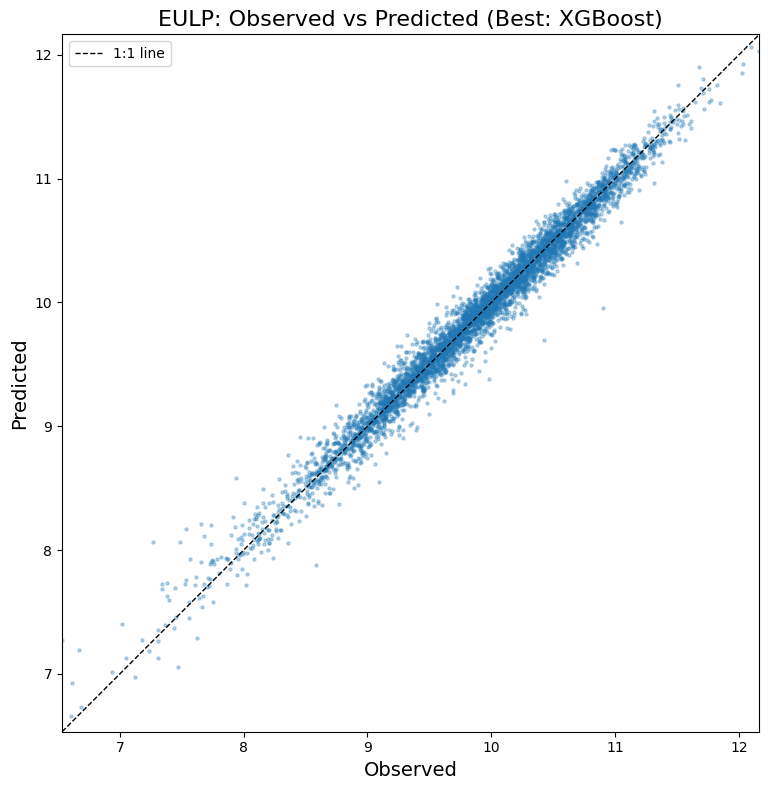

In [17]:
metrics_df = pd.read_csv(MODEL_DIR / "model_metrics_test.csv")
predictions = pd.read_csv(MODEL_DIR / "test_predictions_all_models.csv")

best_row = metrics_df.iloc[0].to_dict()
best_name = best_row["Model"].strip()

best_model = joblib.load(MODEL_DIR / "XGB"/ "XGB_model.joblib")

pred_col = f"pred_{best_name}"
y_pred_best = predictions[pred_col]

print("Best model:", best_name)
print(best_row)

n_plot = min(5000, len(y_test))
plt.figure(figsize=(8, 8))

y_true_plot = y_test[:n_plot]
y_pred_plot = y_pred_best[:n_plot]

plt.scatter(y_true_plot, y_pred_plot, s=5, alpha=0.3)

# 1:1 reference line
min_val = min(y_true_plot.min(), y_pred_plot.min())
max_val = max(y_true_plot.max(), y_pred_plot.max())

plt.plot([min_val, max_val], [min_val, max_val],
         linestyle="--", linewidth=1, color="black", label="1:1 line")
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("Observed", fontsize=14)
plt.ylabel("Predicted", fontsize=14)
plt.title(f"EULP: Observed vs Predicted (Best: {best_name})", fontsize=16)
plt.legend()
plt.tight_layout()

plt.savefig(FIG_DIR / f"obs_vs_pred_{best_name}.png", dpi=600)
plt.show()

## Compute SHAP values

In [31]:
SHAP_SAMPLE_N = min(50000, X_train.shape[0])

X_shap, y_shap, shap_idx = sample_rows(
    X_train,
    y_train,
    n=SHAP_SAMPLE_N,
    random_state=SEED
)

In [32]:
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_shap)

In [33]:
# calculate SHAP base value
base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[0]

print(f"EULP SHAP Base Value: {base_value:.3f}")

SHAP Base Value: 9.896


In [34]:
# --- Save SHAP artifacts ---
# SHAP values
np.save(SHAP_DIR / "xgb_shap_values.npy", shap_values)

# base value
np.save(
    SHAP_DIR / "xgb_shap_base_value.npy",
    np.array([explainer.expected_value])
)

# feature matrix
np.save(SHAP_DIR / "xgb_shap_features.npy", X_shap)

# sample indices
np.save(SHAP_DIR / "xgb_shap_sample_indices.npy", shap_idx)
    # load for later use
    # shap_idx = np.load(MODEL_DIR / "shap_sample_indices.npy")
    # X_shap = X_train.iloc[shap_idx]

In [35]:
with open(MODEL_DIR / "features.json") as f:
    feature_names = json.load(f)
    
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(shap_values).mean(axis=0)
}).sort_values("importance", ascending=False)

shap_importance.to_csv(
    SHAP_DIR / "xgb_shap_feature_importance.csv",
    index=False
)

shap_importance.head(20)

,feature,importance
2,in.sqft,0.266350
7,in.heating_setpoint,0.173567
10,in.infiltration,0.095381
65,in.ashrae_iecc_climate_zone_2004=5A,0.083931
128,in.heating_fuel=Electricity,0.079003
31,in.insulation_wall_r_value,0.067824
60,in.ashrae_iecc_climate_zone_2004=3B,0.066828
223,in.vacancy_status=Occupied,0.063458
11,in.occupants,0.057601
100,in.geometry_building_type_recs=Single-Family D...,0.055770


#### **SHAP sanity check**
It checks: 

    model prediction = base value + sum of feature SHAP contributions
    
For each observation, if the values match (within floating-point tolerance), the SHAP explanations are valid.

In [ ]:
# SHAP sanity check
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

pred = xgb_final.predict(X_shap_df.iloc[[0]])[0]
reconstructed = explainer.expected_value + shap_values[0].sum()

print("Prediction:", pred)
print("SHAP reconstruction:", reconstructed)
print("Difference:", abs(pred - reconstructed))

Notes: 
A very small difference (≈10⁻⁶) is normal due to floating-point precision.

## SHAP plots

### **Importance plot**

In [7]:
# load X_shap
shap_idx = np.load(SHAP_DIR / "xgb_shap_sample_indices.npy")
X_shap = X_train[shap_idx]
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

shap_values = np.load(SHAP_DIR / "xgb_shap_values.npy")

In [16]:
feature_name_map = {
    "in.sqft": "Floor area",
    "in.heating_setpoint": "Baseline heating setpoint",
    "in.infiltration": "Air infiltration rate",
    "in.ashrae_iecc_climate_zone_2004=5A": "IECC climate zone: 5A",
    "in.heating_fuel=Electricity": "Heating fuel: electricity",
    "in.insulation_wall_r_value": "Wall insulation (R-value)",
    "in.ashrae_iecc_climate_zone_2004=3B": "IECC climate zone: 3B",
    "in.vacancy_status=Occupied": "Vacancy status: occupied",
    "in.occupants": "Number of occupants",
    "in.geometry_building_type_recs=Single-Family Detached": "Housing type: single-family detached",
    "in.hvac_cooling_partial_space_conditioning": "Air-conditioned area fraction",
    "in.ashrae_iecc_climate_zone_2004=2A": "IECC climate zone: 2A",
    "in.plug_loads": "Plug load intensity",
    "in.heating_fuel=Other Fuel": "Heating fuel: other",
    "in.hot_water_fixtures": "Hot water usage intensity",
    "in.ashrae_iecc_climate_zone_2004=6A": "IECC climate zone: 6A",
    "in.geometry_building_horizontal_location_mf=Middle": "Unit position: middle",
    "in.insulation_ceiling": "Ceiling insulation (R-value)",
    "in.geometry_stories": "Number of stories",
    "in.cooling_setpoint": "Baseline cooling setpoint",
}

X_shap_df = X_shap_df.rename(columns=feature_name_map)

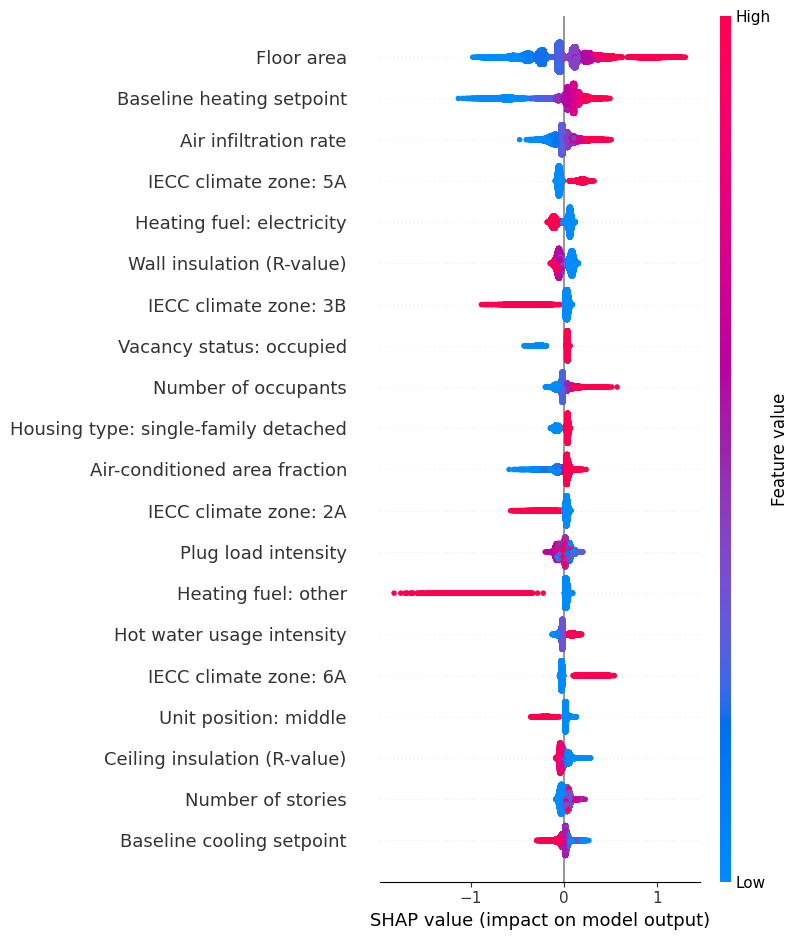

In [17]:
plt.figure()
shap.summary_plot(
    shap_values, 
    X_shap_df,
    max_display=20,
    show=False
)

plt.savefig(
    FIG_DIR / "eulp_shap_summary_beeswarm.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()

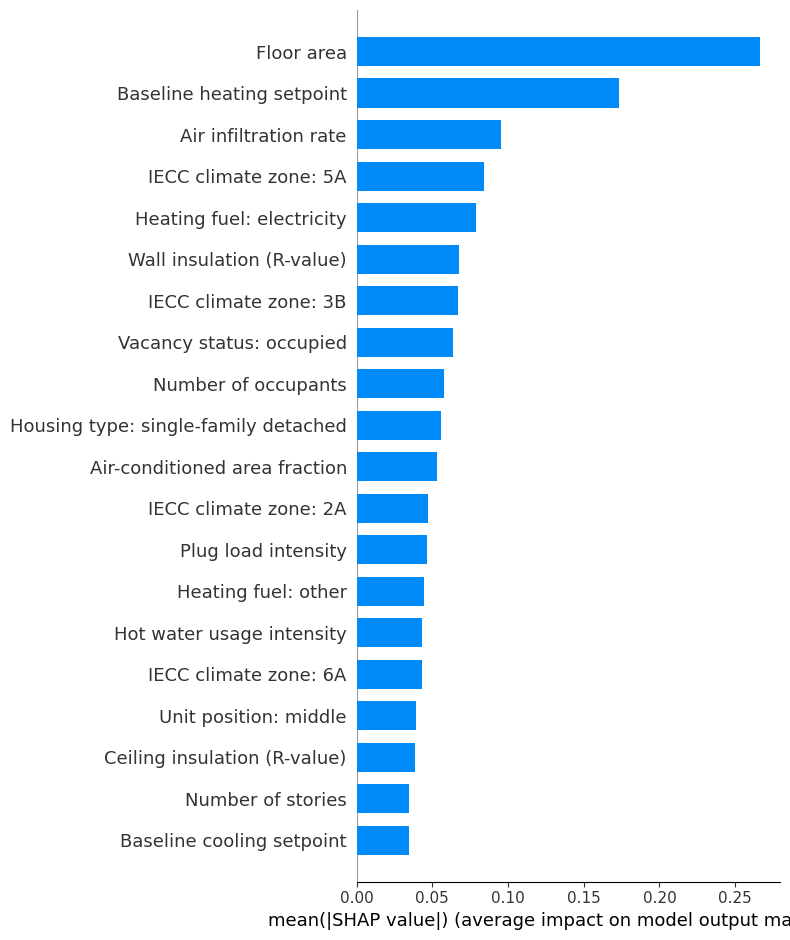

In [18]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_shap_df,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.savefig(
    FIG_DIR / "eulp_shap_feature_importance_bar.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()

### **Dependence plot**

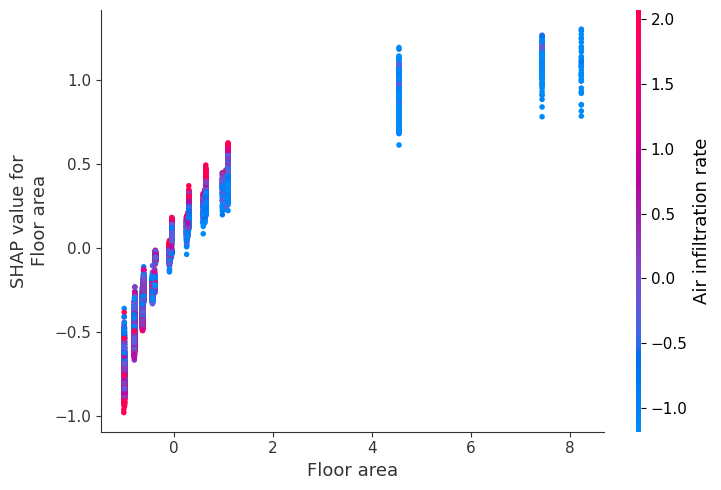

In [19]:
shap.dependence_plot(
    "Floor area",
    shap_values,
    X_shap_df,
    show=False
)

plt.tight_layout()
plt.savefig(FIG_DIR / "shap_dependence_sqft.png", dpi=600, bbox_inches="tight")

plt.show()
plt.close()

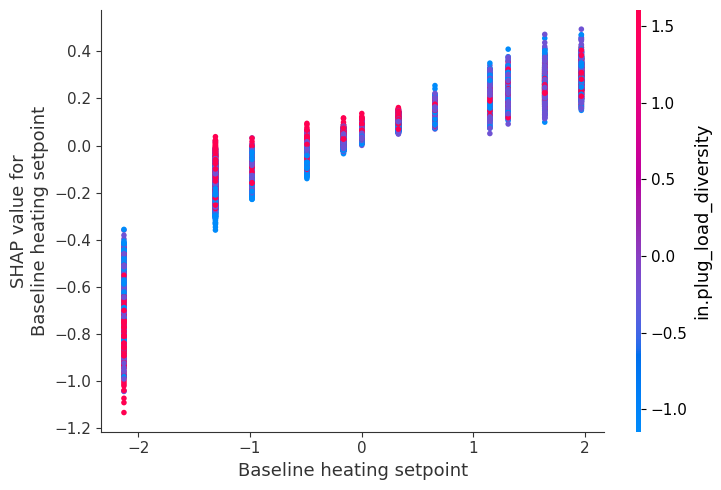

In [20]:
shap.dependence_plot(
    "Baseline heating setpoint",
    shap_values,
    X_shap_df,
    show=False
)

plt.tight_layout()
plt.savefig(FIG_DIR / "shap_dependence_heating_setpoint.png", dpi=600, bbox_inches="tight")

plt.show()
plt.close()

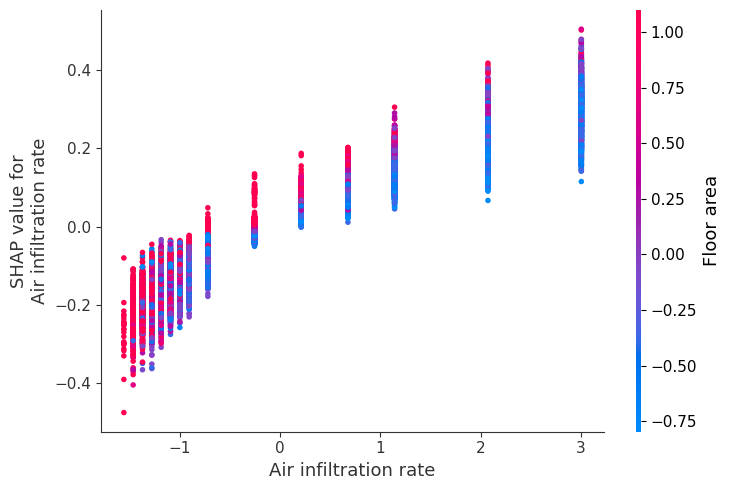

In [21]:
shap.dependence_plot(
    "Air infiltration rate",
    shap_values,
    X_shap_df,
    show=False
)

plt.tight_layout()
plt.savefig(FIG_DIR / "shap_dependence_infiltration.png", dpi=600, bbox_inches="tight")

plt.show()
plt.close()

### **Interactions**

In [23]:
def compute_shap_interactions_batched(explainer, X, batch_size=500):
    
    n = X.shape[0]
    interactions = []

    for i in tqdm(range(0, n, batch_size), desc="Computing SHAP interactions", dynamic_ncols=True):
        
        X_batch = X[i:i + batch_size]

        inter = explainer.shap_interaction_values(X_batch)

        interactions.append(inter)

    return np.concatenate(interactions, axis=0)

In [25]:
SHAP_INTERACTION_N = min(5000, X_train.shape[0])
with open(MODEL_DIR / "features.json") as f:
    feature_names = json.load(f)

X_shap_int, _, _ = sample_rows(
    X_train,
    y_train,
    n=SHAP_INTERACTION_N,
    random_state=SEED
)

X_shap_int_df = pd.DataFrame(X_shap_int, columns=feature_names)

In [43]:
# compute interaction values
def sanitize_feature_names(df_feature):
    df_feature = df_feature.copy()
    df_feature.columns = (
        df_feature.columns
        .astype(str)
        .str.replace(r"[\[\]<]", "", regex=True)   # remove [, ], <
        .str.replace(" ", "_")
    )
    return df_feature

X_shap_int_df = sanitize_feature_names(X_shap_int_df)
    
interaction_values = compute_shap_interactions_batched(
    explainer,
    X_shap_int_df,
    batch_size=500
)

Computing SHAP interactions:   0%|                                                              | 0/10 [00:00<…

In [50]:
np.save(
    SHAP_DIR / "shap_interaction_values.npy",
    interaction_values
)

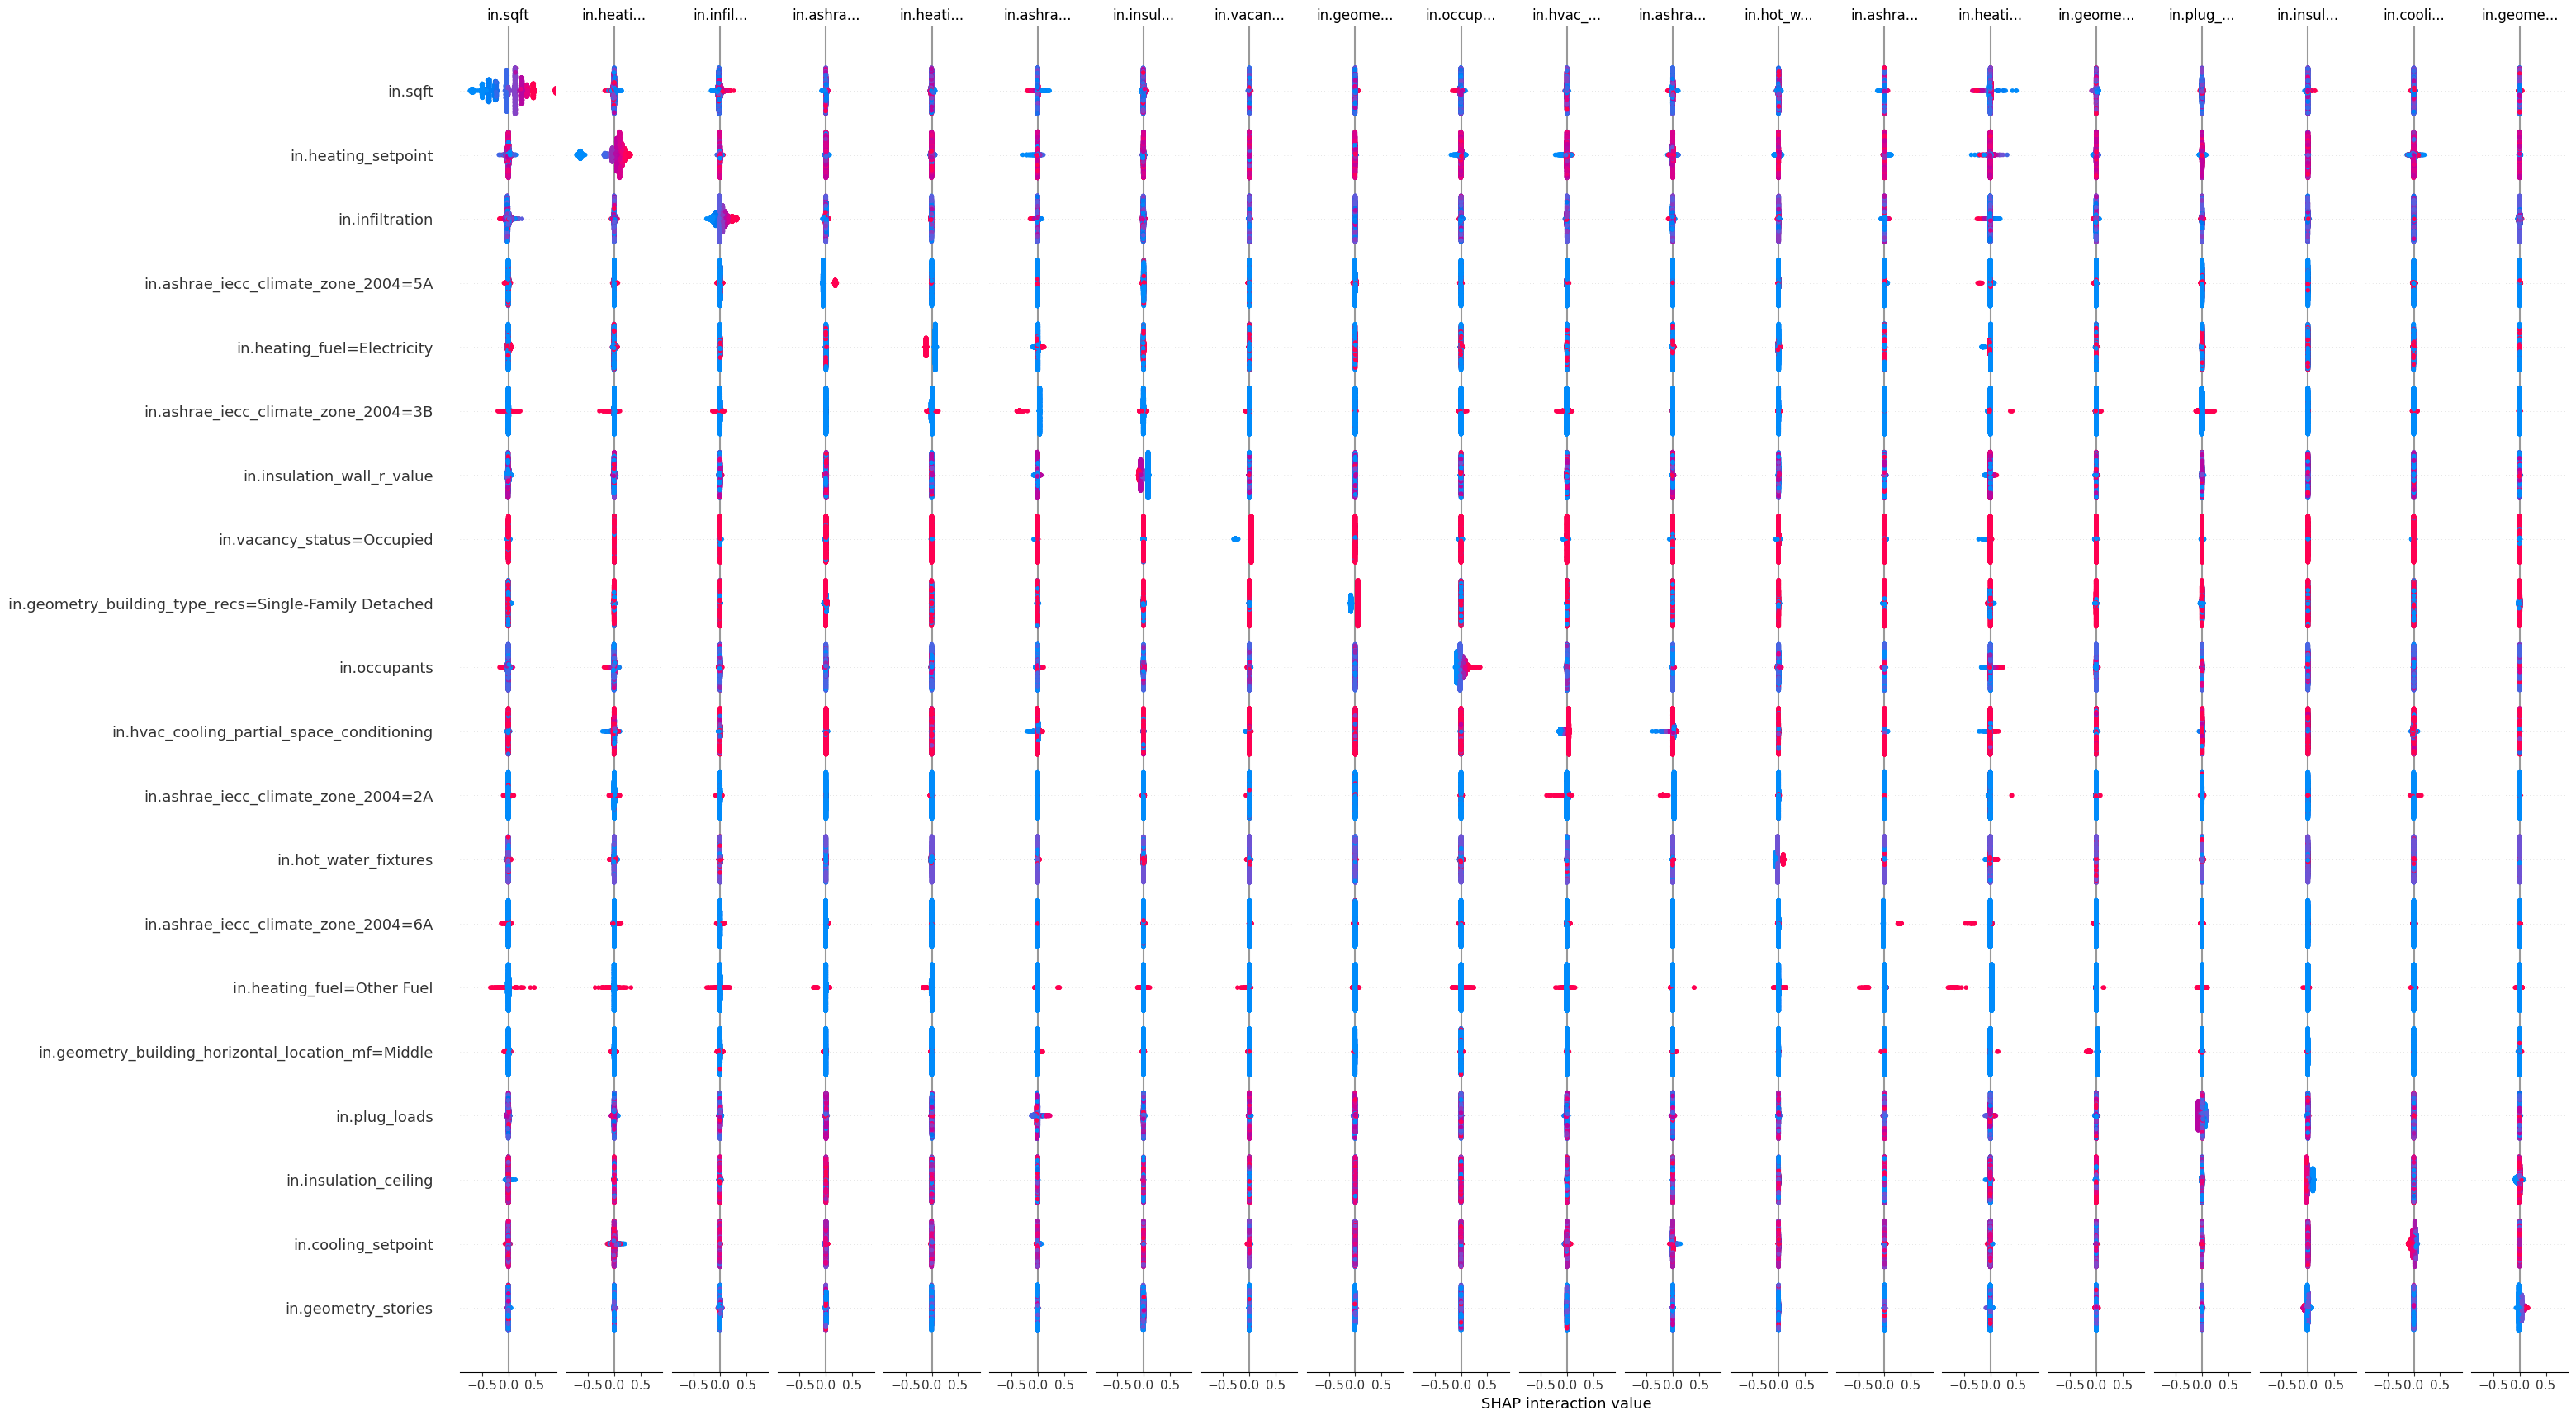

In [27]:
interaction_values = np.load(
    SHAP_DIR / "shap_interaction_values.npy"
)

shap_values = np.load(SHAP_DIR / "xgb_shap_values.npy")

top_features = np.argsort(np.abs(shap_values).mean(0))[-20:]
interaction_subset = interaction_values[:, top_features][:, :, top_features]

X_shap_top = X_shap_int_df.iloc[:, top_features]

shap.summary_plot(
    interaction_subset,
    X_shap_top,
    max_display=20
)

In [46]:
# interaction heatmap
import seaborn as sns

top_feature_names = [feature_names[i] for i in top_features]

interaction_strength = np.abs(interaction_subset).mean(axis=0)

interaction_df = pd.DataFrame(
    interaction_strength,
    index=top_features,
    columns=top_feature_names
)

# remove main SHAP effects (diagonal)
for i in range(len(interaction_df)):
    interaction_df.iloc[i, i] = 0

In [56]:
edges = []

for i in range(len(top_feature_names)):
    for j in range(i+1, len(top_feature_names)):
        strength = interaction_df.iloc[i, j]
        edges.append((top_feature_names[i], top_feature_names[j], strength))

edges_df = pd.DataFrame(edges, columns=["Feature_A","Feature_B","Interaction_Strength"])

edges_df = edges_df.sort_values(
    "Interaction_Strength",
    ascending=False
).reset_index(drop=True)

edges_df.to_csv(
    SHAP_DIR / "xgb_shap_interaction_strength.csv",
    index=False
)

edges_df.head(20)

,Feature_A,Feature_B,Interaction_Strength
0,in.infiltration,in.sqft,0.012793
1,in.geometry_stories,in.insulation_ceiling,0.010320
2,in.plug_loads,in.ashrae_iecc_climate_zone_2004=3B,0.008102
3,in.cooling_setpoint,in.heating_setpoint,0.007699
4,in.ashrae_iecc_climate_zone_2004=3B,in.heating_fuel=Electricity,0.007110
5,in.ashrae_iecc_climate_zone_2004=2A,in.hvac_cooling_partial_space_conditioning,0.007079
6,in.heating_setpoint,in.sqft,0.006511
7,in.hvac_cooling_partial_space_conditioning,in.heating_setpoint,0.005923
8,in.occupants,in.heating_setpoint,0.005520
9,in.hvac_cooling_partial_space_conditioning,in.ashrae_iecc_climate_zone_2004=3B,0.005505


In [52]:
# Compute global interaction share
import numpy as np

interaction_matrix = np.abs(interaction_subset)

# main effects (diagonal)
main_effect = np.abs(shap_values).mean()

# off-diagonal interactions only
mask = ~np.eye(interaction_matrix.shape[1], dtype=bool)

interaction_effect = interaction_matrix[:, mask].mean()

interaction_share = interaction_effect / main_effect

print("interaction share:", interaction_share)

interaction share: 0.25265527


In [54]:
interaction_per_feature = np.abs(interaction_subset).mean(axis=0)

interaction_df = pd.DataFrame(
    interaction_per_feature,
    index=top_feature_names,
    columns=top_feature_names
)

interaction_df.sum(axis=1).sort_values(ascending=False).head(10)

in.sqft                                                  0.338175
in.heating_setpoint                                      0.237935
in.infiltration                                          0.147360
in.heating_fuel=Electricity                              0.127086
in.ashrae_iecc_climate_zone_2004=5A                      0.117492
in.ashrae_iecc_climate_zone_2004=3B                      0.112503
in.insulation_wall_r_value                               0.103359
in.hvac_cooling_partial_space_conditioning               0.092631
in.occupants                                             0.090956
in.geometry_building_type_recs=Single-Family Detached    0.088639
dtype: float32